In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import pandas as pd
import seaborn as sns

from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

from Transformer import TransformerClassifier, MyDataset, create_padding_mask

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
raw_train_data = torch.load("Train_data_h2",weights_only = True)
raw_train_classes = torch.load("Train_classes_h2",weights_only = True)

raw_test_data = torch.load("Test_data_G",weights_only=True)
raw_test_classes = torch.load("Test_classes_G",weights_only=True)

In [4]:
raw_test_classes.shape, sum(raw_test_classes)

(torch.Size([4345, 1]), tensor([1305]))

In [5]:
raw_train_classes.shape, sum(raw_train_classes)

(torch.Size([2940, 1]), tensor([1464.]))

In [6]:
# scaler = StandardScaler()

# reshaped_train_data = raw_train_data.reshape(-1, 12)
# reshaped_test_data = raw_test_data.reshape(-1,12)

# scaler.fit(reshaped_train_data)

# scaled_train_data = scaler.transform(reshaped_train_data)
# scaled_test_data = scaler.transform(reshaped_test_data)

# train_data = scaled_train_data.reshape(raw_train_data.shape[0],raw_train_data.shape[1],raw_train_data.shape[2])
# test_data = scaled_test_data.reshape(raw_test_data.shape[0],raw_test_data.shape[1],raw_test_data.shape[2])

# train_data = torch.from_numpy(train_data).float().to(device)
# test_data = torch.from_numpy(test_data).float().to(device)


# train_classes = raw_train_classes.float().to(device)
# test_classes = raw_test_classes.float().to(device)
# train_data.shape, train_classes.shape, test_data.shape, test_classes.shape

In [7]:
train_data = raw_train_data.float().to(device)
test_data = raw_test_data.float().to(device)
train_classes = raw_train_classes.float().to(device)
test_classes = raw_test_classes.float().to(device)


train_data.shape, train_classes.shape, test_data.shape, test_classes.shape

(torch.Size([2940, 600, 12]),
 torch.Size([2940, 1]),
 torch.Size([4345, 600, 12]),
 torch.Size([4345, 1]))

In [8]:
if torch.isnan(raw_train_data).any():
    print("Input tensor contains NaN values!")
    print(f"{torch.isnan(raw_train_data).sum().item()} NaNs")
else:
    print("Inputs good")

if torch.isinf(raw_train_data).any():
    print("Input tensor contains Inf values!")
    print(f"{torch.isinf(raw_train_data).sum().item()} Infs")
else:
    print("Inputs good")

Inputs good
Inputs good


In [9]:
if torch.isnan(raw_test_data).any():
    print("Input tensor contains NaN values!")
    print(f"{torch.isnan(raw_test_data).sum().item()} NaNs")
else:
    print("Inputs good")

if torch.isinf(raw_test_data).any():
    print("Input tensor contains Inf values!")
    print(f"{torch.isinf(raw_test_data).sum().item()} Infs")
else:
    print("Inputs good")

Inputs good
Inputs good


In [10]:
train_dataset = MyDataset(train_data, train_classes)
test_dataset = MyDataset(test_data, test_classes)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=True)

In [11]:
epochs = 80
models = []
train_losses = []
test_losses = []
test_accuracies = []

dim_feedforward = 12
input_dim = 12  # Number of features
d_model = 12  # Transformer model dimension
num_heads = 4   # Number of attention heads
num_layers = 2  # Number of transformer layers
dropout = 0.25   # Dropout rate

model = TransformerClassifier(input_dim, d_model, num_heads, num_layers, dim_feedforward, dropout).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.00005)
criterion = nn.BCEWithLogitsLoss()
model.train()


for epoch in range(1,epochs+1):

    model.train()
    running_loss = 0.0
    num_batches = 0

    for batch_data, batch_labels in train_dataloader:
        output = model(batch_data)      
        loss = criterion(output, batch_labels)
        optimizer.zero_grad()  
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1
    
    epoch_loss = running_loss / num_batches
    print(f"epoch {epoch} loss: {epoch_loss}")
    train_losses.append(epoch_loss)

    test_result = []
    
    #model.eval()
    running_test_loss = 0.0
    num_test_batches = 0
    with torch.no_grad():
        for batch_test_data, batch_test_labels in test_dataloader:
            test_output = model(batch_test_data)
            test_loss = criterion(test_output,batch_test_labels)
            running_test_loss += test_loss.item()
            num_test_batches += 1
            test_probability = torch.sigmoid(test_output)
            test_prediction = torch.round(test_probability)
            test_result.append((test_prediction==batch_test_labels).float())

    epoch_test_loss = running_test_loss / num_test_batches
    test_losses.append(epoch_test_loss)
    
    t_result = torch.cat(test_result)
    test_accuracy = (sum(t_result).cpu().numpy())/len(t_result)
    test_accuracies.append(test_accuracy)

c:\Users\a3ebadi\.conda\envs\x\lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


epoch 1 loss: 0.7044360346120336
epoch 2 loss: 0.6872085119071214
epoch 3 loss: 0.6759657496991365
epoch 4 loss: 0.6676809969155685
epoch 5 loss: 0.6612887278847073
epoch 6 loss: 0.6552876843058545
epoch 7 loss: 0.6499329701713894
epoch 8 loss: 0.6453536722971045
epoch 9 loss: 0.6407742331857267
epoch 10 loss: 0.6362500449885493
epoch 11 loss: 0.6321086261583411
epoch 12 loss: 0.628198772020962
epoch 13 loss: 0.6238899431798769
epoch 14 loss: 0.619930151688016
epoch 15 loss: 0.6164334234984025
epoch 16 loss: 0.6128007105511167
epoch 17 loss: 0.6093981201234071
epoch 18 loss: 0.6058338647303374
epoch 19 loss: 0.6029498029662215
epoch 20 loss: 0.599594349446504
epoch 21 loss: 0.5967169873740362
epoch 22 loss: 0.5950811453487562
epoch 23 loss: 0.5916809514164925
epoch 24 loss: 0.5879277194971624
epoch 25 loss: 0.5869083067645198
epoch 26 loss: 0.5847733519647432
epoch 27 loss: 0.58172338164371
epoch 28 loss: 0.5804273991481118
epoch 29 loss: 0.5782708010595777
epoch 30 loss: 0.57663452463

In [12]:
t_result.shape

torch.Size([4345, 1])

In [13]:
sum(t_result).cpu().numpy()

array([3866.], dtype=float32)

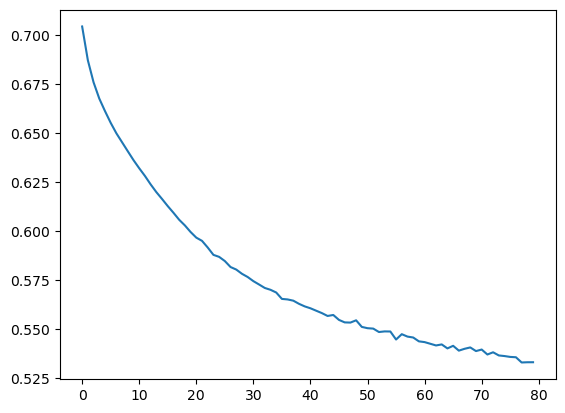

In [14]:
plt.plot(train_losses)

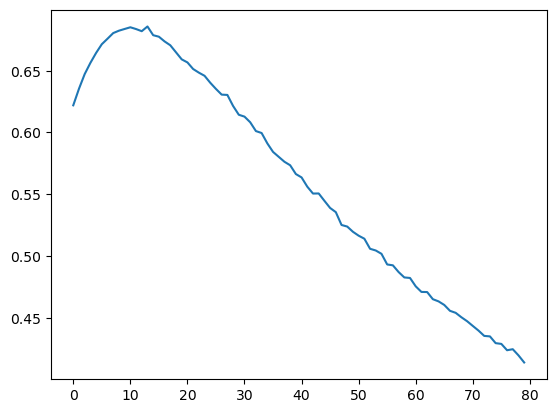

In [15]:
plt.plot(test_losses)

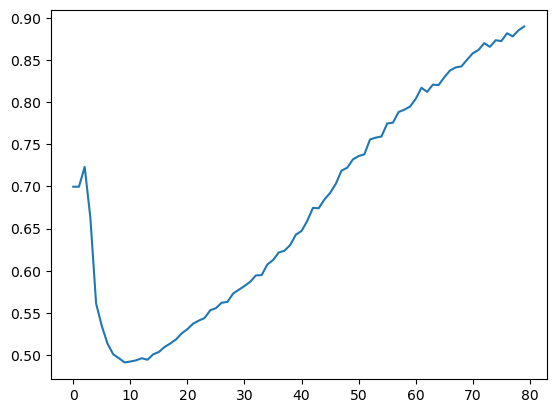

In [16]:
plt.plot(test_accuracies)

In [17]:
#torch.save(model, 'model24_n_4_2a.pth')

ROC Curve Generation

In [23]:
probabilities = []
predictions = []
true_labels = []

#model.eval()
with torch.no_grad():
        for batch_test_data, batch_test_labels in test_dataloader:
            test_output = model(batch_test_data)
            test_probability = torch.sigmoid(test_output)
            probabilities.append(test_probability)
            test_pred = torch.round(test_probability)
            predictions.append(test_pred)
            true_labels.append(batch_test_labels)

y_pred = torch.cat(predictions).cpu().numpy()
y_prob = torch.cat(probabilities).cpu().numpy()
y_true = torch.cat(true_labels).cpu().numpy()

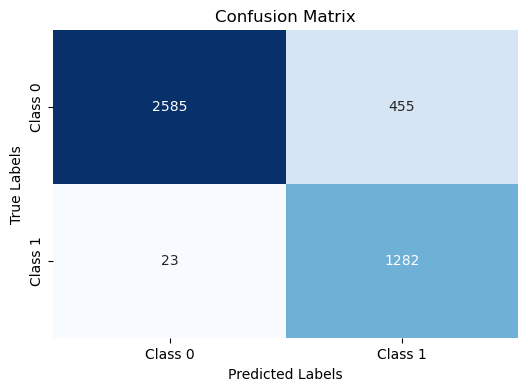

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Add labels, title, and axis ticks
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix')

# Add custom class labels (optional, if binary classification)
ax.xaxis.set_ticklabels(['Class 0', 'Class 1'])
ax.yaxis.set_ticklabels(['Class 0', 'Class 1'])

plt.show()

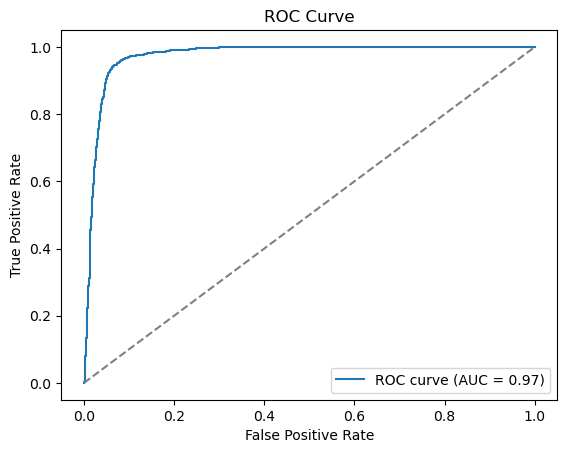

In [25]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [21]:
for name,param in model.named_parameters():
    print(name,param,param.shape)

projection.weight Parameter containing:
tensor([[ 0.3550,  0.1700, -0.3210,  0.0251, -0.1959, -0.2287, -0.2372, -0.1878,
         -0.0834,  0.4975,  0.2915,  0.0921],
        [-0.3453,  0.0323,  0.0527, -0.1428, -0.1525,  0.2678, -0.1832, -0.1492,
          0.0894, -0.2921, -0.1577, -0.0409],
        [-0.1937, -0.1649, -0.1455,  0.2290, -0.0878,  0.0475,  0.2724,  0.0056,
          0.1434, -0.4975, -0.0784, -0.2589],
        [-0.5350,  0.0870, -0.0654, -0.1536,  0.1066,  0.2573,  0.3056,  0.1091,
         -0.3016, -0.5152,  0.0053,  0.2108],
        [-0.3449, -0.1829,  0.0038, -0.3040,  0.1368,  0.0374, -0.1186,  0.1918,
         -0.1613, -0.0749, -0.1592, -0.0949],
        [ 0.0425,  0.1027,  0.0950,  0.2114, -0.0125,  0.1454,  0.1711,  0.0725,
         -0.2328, -0.1974,  0.1222, -0.1302],
        [ 0.0130,  0.0465, -0.2306,  0.3345, -0.0675,  0.2580, -0.2241, -0.0747,
         -0.1741, -0.1036, -0.1589, -0.3109],
        [-0.0204, -0.1012,  0.0690,  0.0636, -0.1860,  0.1223, -0.1406,

In [22]:
sum(y_true), sum(y_pred)

(array([1305.], dtype=float32), array([1737.], dtype=float32))